In [55]:
import pandas as pd
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
import math
from matplotlib.ticker import MultipleLocator

%matplotlib inline

In [18]:
all_books = pd.read_csv('DocumentMetadata.csv', parse_dates=['EntryCreationDate'])
days_read = pd.read_csv('ReadingInsightsDayUnits.csv', parse_dates=['reading_tracked_on_day'])
book_session = pd.read_csv('reading-insights-sessions.csv', parse_dates=['end_time', 'start_time'])
session = pd.read_csv('ReadingSession.csv', parse_dates=['start_timestamp', 'end_timestamp'])
completed_books = pd.read_csv('TitlesCompleted.csv')

In [19]:
session = session[session['total_reading_millis'].notna()].copy()

In [20]:
session['start_date'] = pd.to_datetime(session['start_timestamp'])
session['start_date'] = session['start_date'].dt.date

session['end_date'] = pd.to_datetime(session['end_timestamp'])
session['end_date'] = session['end_date'].dt.date

In [21]:
read_per_day = session.groupby('start_date')['total_reading_millis'].sum().reset_index()
read_per_day['total_minutes'] = (read_per_day['total_reading_millis']/60000).round(2)
read_per_day['total_hours'] = (read_per_day['total_reading_millis']/3600000).round(2)

In [22]:
read_per_day.sort_values(by='start_date', ascending=False)

,start_date,total_reading_millis,total_minutes,total_hours
45,2026-02-19,15200.0,0.25,0.00
44,2026-02-11,9900600.0,165.01,2.75
43,2026-02-10,2956600.0,49.28,0.82
42,2026-02-09,14202500.0,236.71,3.95
41,2026-02-08,16574000.0,276.23,4.60
40,2026-02-07,18731700.0,312.20,5.20
39,2026-02-06,9756200.0,162.60,2.71
38,2026-02-05,8172200.0,136.20,2.27
37,2026-02-04,7652400.0,127.54,2.13
36,2026-02-03,3586500.0,59.78,1.00


In [23]:
total_reading_sec = (session['total_reading_millis'].sum()/1000).round(2)
total_reading_mins = (session['total_reading_millis'].sum()/60000).round(2)
total_reading_hours = (session['total_reading_millis'].sum()/3600000).round(2)
total_reading_days = (session['total_reading_millis'].sum()/86400000).round(2)

In [28]:
total_reading_sec

np.float64(2977.5999999999767)

In [24]:
days = int(total_reading_sec // (24 * 3600))
total_reading_sec %= (24 * 3600)

In [25]:
hours = int(total_reading_sec // 3600)
total_reading_sec %= 3600

In [26]:
minutes = int(total_reading_sec // 60)
seconds = int(total_reading_sec % 60)

In [27]:
print(f"Total Time Spent Reading: {int(days)} days, {int(hours)} hours, {int(minutes)} minutes, and {int(seconds)} seconds.")

Total Time Spent Reading: 3 days, 2 hours, 49 minutes, and 37 seconds.


In [30]:
read_per_day

,start_date,total_reading_millis,total_minutes,total_hours
0,2025-12-27,286300.0,4.77,0.08
1,2025-12-28,9318100.0,155.30,2.59
2,2025-12-29,4891000.0,81.52,1.36
3,2025-12-30,4739000.0,78.98,1.32
4,2025-12-31,4529100.0,75.48,1.26
5,2026-01-01,2952100.0,49.20,0.82
6,2026-01-02,1264100.0,21.07,0.35
7,2026-01-03,5569200.0,92.82,1.55
8,2026-01-04,2934500.0,48.91,0.82
9,2026-01-05,3269400.0,54.49,0.91


C:\Users\Alia.Sabado\AppData\Local\Temp\ipykernel_28288\1640766294.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  g = sns.lineplot(data=read_per_day, y='total_minutes', x='start_date', palette='pastel')


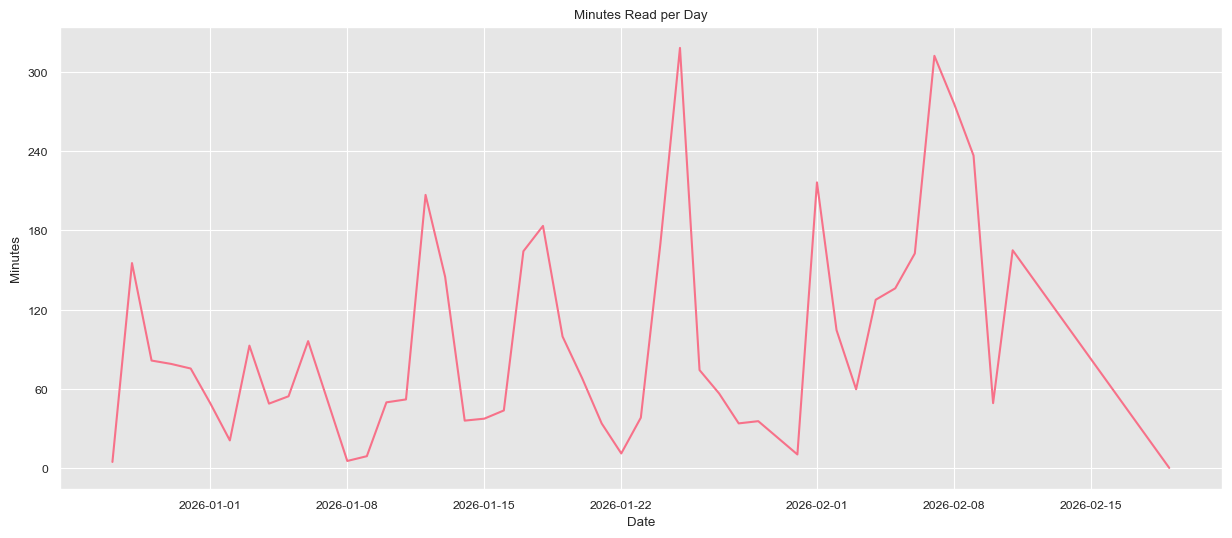

In [75]:
plt.figure(figsize=(15,6))
sns.set_theme()
sns.set_palette(sns.color_palette("husl", 8))
#sns.set_context(rc={'lines.linewidth': 2})
sns.set_context("paper", rc={'lines.linewidth': 1.5})
sns.set_style("darkgrid", {"axes.facecolor": ".9"})
g = sns.lineplot(data=read_per_day, y='total_minutes', x='start_date', palette='pastel')
g.set(xlabel='Date', ylabel='Minutes', title='Minutes Read per Day')
g.yaxis.set_major_locator(MultipleLocator(60))
plt.show()

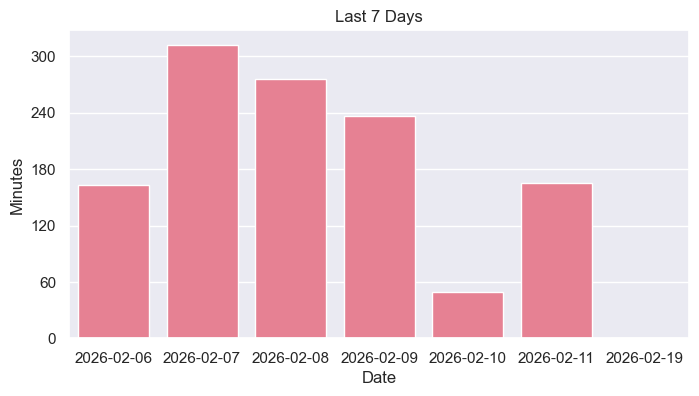

In [83]:
last7days = read_per_day.tail(7)
plt.figure(figsize=(8,4))
sns.set_theme()
sns.set_palette(sns.color_palette("husl", 8))
g = sns.barplot(data=last7days, y='total_minutes', x='start_date')
g.set(xlabel='Date', ylabel='Minutes', title='Last 7 Days')
g.yaxis.set_major_locator(MultipleLocator(60))
plt.show()